<h1>WWTW CNN: Aerobic Zone / Clarifier Classifier</h1>

**Structure:**
1. Imports & config
2. Load dataset (`ImageFolder`) and split into train / validation / test
3. Inspect a batch of images
4. Define the CNN
5. Train
6. Evaluate (accuracy + confusion matrix)
7. Save the trained model

Set `COMPONENT` below to `"aerobic_zone"` or `"clarifier"` depending on which
classifier you're training

In [1]:
# preamble - imports
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. Config

Points at the output of `prep.py`. 

In [2]:
# ------------------------- CONFIG -------------------------

DATASET_ROOT = Path("../cnn_dataset")
COMPONENT = "aerobic_zone" # "aerobic_zone" or "clarifier"

if COMPONENT == "aerobic_zone":
    IMG_SIZE = (96, 192)  # 2:1 ratio for rectangular crops
else:
    IMG_SIZE = (128, 128) # Square for clarifiers
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100

# Regularization & Early Stopping config
WEIGHT_DECAY = 1e-4 
PATIENCE = 12

VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SEED = 42

MODEL_SAVE_PATH = Path(f"../models/{COMPONENT}_cnn.pt")

# ------------------------------------------------------------------

data_dir = DATASET_ROOT / COMPONENT
assert data_dir.exists(), f"Dataset folder not found: {data_dir}. Run prep.py first."

torch.manual_seed(SEED)

# 2. Load dataset

`ImageFolder` treats each subfolder name as a class label — this lines up
directly with the `Functional/`, `Suboptimal/`, `Dysfunctional/`, etc. folders
produced by `prep.py`.

Train and eval use different transforms (train gets light augmentation), so we
build two `ImageFolder` instances over the same data and split by *indices* to
keep the same images in each split for both.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

full_dataset_train_tf = datasets.ImageFolder(root=data_dir, transform=train_transform)
full_dataset_eval_tf = datasets.ImageFolder(root=data_dir, transform=eval_transform)

class_names = full_dataset_train_tf.classes
num_classes = len(class_names)
print(f"Classes found ({num_classes}): {class_names}")

n_total = len(full_dataset_train_tf)
n_val = int(n_total * VAL_FRACTION)
n_test = int(n_total * TEST_FRACTION)
n_train = n_total - n_val - n_test

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx, test_idx = random_split(
    range(n_total), [n_train, n_val, n_test], generator=generator
)

train_ds = torch.utils.data.Subset(full_dataset_train_tf, train_idx.indices)
val_ds = torch.utils.data.Subset(full_dataset_eval_tf, val_idx.indices)
test_ds = torch.utils.data.Subset(full_dataset_eval_tf, test_idx.indices)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Suboptimal']
Train: 1206 | Val: 258 | Test: 258


## Check class balance

Worth looking at before training — if one class dominates, plain accuracy
will be misleading and you may want class weighting in the loss function.

  Dysfunctional  : 805
  Empty          : 1
  Functional     : 693
  Suboptimal     : 223


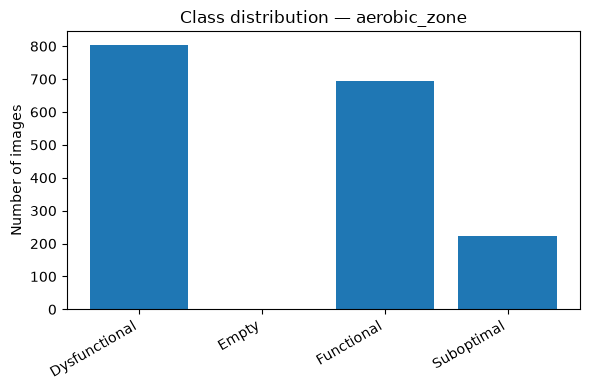

In [4]:
counts = np.bincount([label for _, label in full_dataset_train_tf.samples], minlength=num_classes)
for name, count in zip(class_names, counts):
    print(f"  {name:15s}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts)
plt.ylabel("Number of images")
plt.title(f"Class distribution — {COMPONENT}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 3. Inspect a batch

Quick sanity check that images and labels are loading correctly before
spending time training.

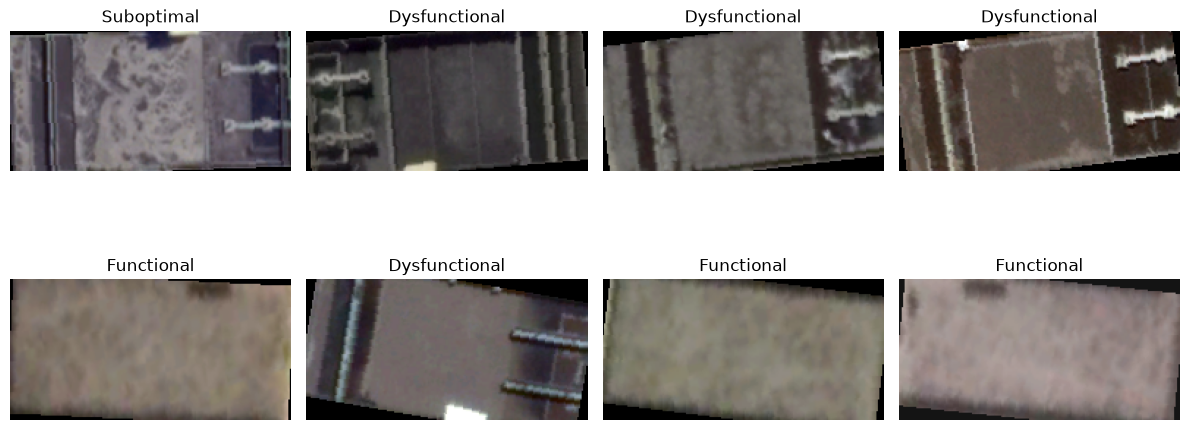

In [5]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

# 4. Define the CNN

A small convolutional network to start from — three conv blocks (conv → ReLU
→ max-pool) followed by two fully-connected layers. This is a reasonable
baseline for a few thousand images at 128x128; it's easy to make deeper or
swap for a pretrained backbone (e.g. `torchvision.models.resnet18`) later if
accuracy plateaus.

In [6]:
class WWTWClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # Example feature extractor 
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        # Smashes any HxW down to 1x1, preserving the 128 channels
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5), # Stronger dropout for regularization
            nn.Linear(128, num_classes) # Always 128 because of AdaptiveAvgPool2d
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = WWTWClassifier(num_classes).to(device)

# Add weight decay to the optimizer
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

# 5. Instantiate model, loss, and optimizer

`CrossEntropyLoss` expects raw logits (no softmax needed in the model output),
matching the convention from the practical.

In [7]:
model = WWTWClassifier(num_classes=num_classes).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

WWTWClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=128, out_features=4, bias=True)
  )
)


# 6. Training loop

In [9]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    
    # --- EARLY STOPPING & CHECKPOINTING ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0
        # Save the best model
        MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement in val loss for {epochs_without_improvement} epoch(s).")
        
        if epochs_without_improvement >= PATIENCE:
            print(f"\\nEarly stopping triggered! Restoring best model from Epoch {epoch+1 - PATIENCE}")
            break

# Load the best weights back in before testing
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

Epoch [1/100] Train Loss: 0.9676 Acc: 0.5390 | Val Loss: 0.9171 Acc: 0.5659
Epoch [2/100] Train Loss: 0.9145 Acc: 0.5804 | Val Loss: 0.9103 Acc: 0.5814
Epoch [3/100] Train Loss: 0.9034 Acc: 0.5862 | Val Loss: 0.9319 Acc: 0.5426
  -> No improvement in val loss for 1 epoch(s).
Epoch [4/100] Train Loss: 0.9089 Acc: 0.5788 | Val Loss: 0.9111 Acc: 0.5814
  -> No improvement in val loss for 2 epoch(s).
Epoch [5/100] Train Loss: 0.8934 Acc: 0.5978 | Val Loss: 0.9240 Acc: 0.5620
  -> No improvement in val loss for 3 epoch(s).
Epoch [6/100] Train Loss: 0.8964 Acc: 0.5929 | Val Loss: 0.9208 Acc: 0.5775
  -> No improvement in val loss for 4 epoch(s).
Epoch [7/100] Train Loss: 0.8857 Acc: 0.5945 | Val Loss: 0.8811 Acc: 0.6008
Epoch [8/100] Train Loss: 0.8746 Acc: 0.6028 | Val Loss: 0.8583 Acc: 0.6318
Epoch [9/100] Train Loss: 0.8873 Acc: 0.6012 | Val Loss: 0.8908 Acc: 0.5969
  -> No improvement in val loss for 1 epoch(s).
Epoch [10/100] Train Loss: 0.8621 Acc: 0.6227 | Val Loss: 0.9564 Acc: 0.5736

<All keys matched successfully>

## Training curves

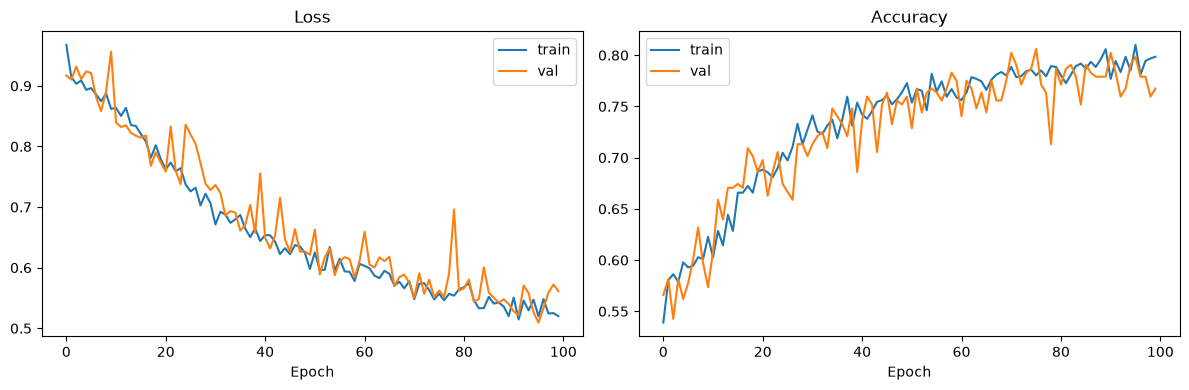

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # Included just in case you need it!

# Plot Loss
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Plot Accuracy
axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. Evaluate on the test set

Test set was held out entirely from training/validation, so this gives an
unbiased read on final performance. The confusion matrix is worth reading
closely here — for this problem, false "Functional" calls on a genuinely
Dysfunctional unit matter more than the reverse, so it's worth checking which
direction the model's mistakes lean.

Test accuracy: 0.725


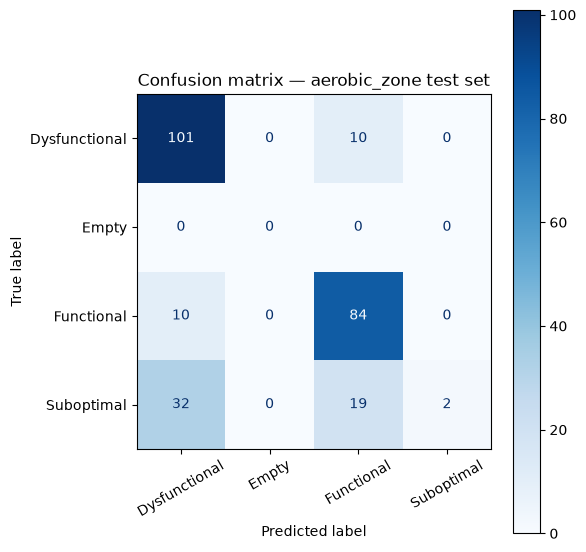

In [12]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_hat = model(images)
        preds = y_hat.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy: {test_acc:.3f}")

# Force the matrix to build a grid for all known classes using their integer indices (0 to 3)
cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {COMPONENT} test set")
plt.tight_layout()
plt.show()

# 8. Save the trained model

In [13]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "component": COMPONENT,
}, MODEL_SAVE_PATH)

print(f"Saved model to {MODEL_SAVE_PATH}")

Saved model to ../models/aerobic_zone_cnn.pt


# Next steps

Some things worth trying once this baseline is working:

- **Class imbalance** — if the class distribution plot above is skewed (likely,
  given Dysfunctional/Suboptimal counts differ a lot from Functional), try
  `nn.CrossEntropyLoss(weight=...)` with inverse-frequency class weights, or
  oversampling the minority classes.
- **Transfer learning** — swap `WWTW_CNN` for a pretrained backbone
  (`torchvision.models.resnet18(weights="IMAGENET1K_V1")`) with the final layer
  replaced, especially if the dataset stays a few hundred images per class.
- **Cross-facility generalisation** — since the thesis scope covers three
  facilities, it's worth checking whether training on two facilities and
  testing on the third holds up, not just a random split across all three.
- **Grad-CAM / filter visualisation** — similar to what practical 5 did with
  `plot_filters`, visualising which parts of the image the CNN attends to
  would make a strong addition to the Results chapter, and doubles as a sanity
  check that it's actually looking at the aerator/clarifier surface and not
  some unrelated artifact.